In [1]:
# ─── Kütüphanelerin İçe Aktarılması ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler hazır ✓")

Kütüphaneler hazır ✓


In [2]:
# ─── Veri Setinin Yüklenmesi ──────────────────────────────────────────────────
# Adult Income: bir kişinin yıllık gelirinin 50.000 doları aşıp aşmadığını tahmin etme
sutunlar = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
            "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
            "hours_per_week", "native_country", "income"]

df = pd.read_csv("adult_income.csv.gz", header=None, names=sutunlar, skipinitialspace=True)

print(f"Boyut: {df.shape[0]:,} kişi × {df.shape[1]} sütun")
df.head()

Boyut: 48,842 kişi × 15 sütun


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# ─── Hedef Değişken ve Veri Sağlığı ───────────────────────────────────────────
print("Gelir dağılımı:")
print(df["income"].value_counts())
print(f"\n>50K oranı: %{(df['income'] == '>50K').mean()*100:.1f}")

print(f"\nNaN değer: {df.isnull().sum().sum()}")
print("\nAma '?' ile gizlenmiş eksik değerler var:")
for c in df.columns:
    if df[c].dtype == object:
        n = (df[c] == "?").sum()
        if n:
            print(f"  {c}: {n:,}")

Gelir dağılımı:


income
<=50K    37155
>50K     11687
Name: count, dtype: int64

>50K oranı: %23.9

NaN değer: 0

Ama '?' ile gizlenmiş eksik değerler var:


In [4]:
# ─── Ön İşleme ────────────────────────────────────────────────────────────────
df_temiz = df.replace("?", np.nan)

oncesi = len(df_temiz)
df_temiz = df_temiz.dropna()                        # eksik satırları at
print(f"Eksik değer temizliği: {oncesi:,} → {len(df_temiz):,}")

oncesi = len(df_temiz)
df_temiz = df_temiz.drop_duplicates().reset_index(drop=True)
print(f"Duplicate temizliği  : {oncesi:,} → {len(df_temiz):,}")

# fnlwgt: anket ağırlığı, kişinin gelirini açıklamaz -> çıkarılıyor
df_temiz = df_temiz.drop(columns=["fnlwgt"])
print(f"\nSon boyut: {df_temiz.shape}")

Eksik değer temizliği: 48,842 → 45,222
Duplicate temizliği  : 45,222 → 45,175

Son boyut: (45175, 14)


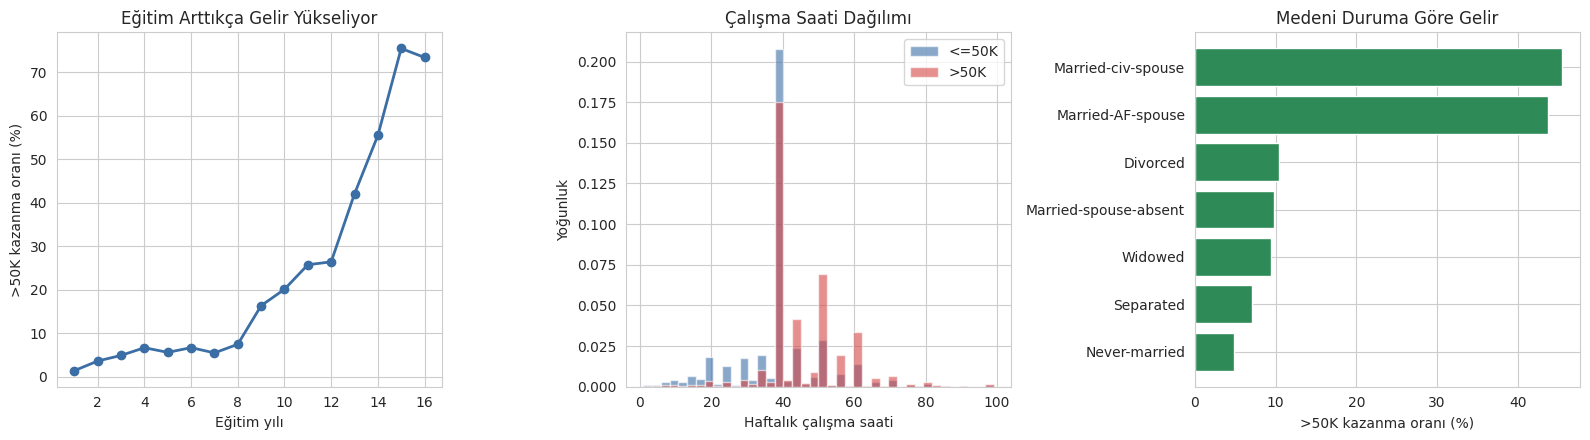

In [5]:
# ─── Görsel Keşif ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) Eğitim yılı ile gelir ilişkisi
egitim = df_temiz.groupby("education_num")["income"].apply(lambda s: (s == ">50K").mean())
axes[0].plot(egitim.index, egitim.values * 100, "o-", color="#3b6ea5", linewidth=2)
axes[0].set_xlabel("Eğitim yılı"); axes[0].set_ylabel(">50K kazanma oranı (%)")
axes[0].set_title("Eğitim Arttıkça Gelir Yükseliyor")

# 2) Haftalık çalışma saati
axes[1].hist(df_temiz.loc[df_temiz["income"] == "<=50K", "hours_per_week"], bins=40,
             alpha=0.6, color="#3b6ea5", label="<=50K", density=True)
axes[1].hist(df_temiz.loc[df_temiz["income"] == ">50K", "hours_per_week"], bins=40,
             alpha=0.6, color="#d64545", label=">50K", density=True)
axes[1].set_xlabel("Haftalık çalışma saati"); axes[1].set_ylabel("Yoğunluk")
axes[1].set_title("Çalışma Saati Dağılımı"); axes[1].legend()

# 3) Medeni duruma göre gelir
medeni = df_temiz.groupby("marital_status")["income"].apply(
    lambda s: (s == ">50K").mean()).sort_values()
axes[2].barh(medeni.index, medeni.values * 100, color="#2e8b57")
axes[2].set_xlabel(">50K kazanma oranı (%)")
axes[2].set_title("Medeni Duruma Göre Gelir")

plt.tight_layout()
plt.show()

In [6]:
# ─── Özellik / Hedef Ayrımı ve Kodlama ────────────────────────────────────────
y = (df_temiz["income"] == ">50K").astype(int)          # 1 = 50K üzeri
X = pd.get_dummies(df_temiz.drop(columns=["income"]), drop_first=True)

print(f"Kodlama sonrası özellik sayısı: {X.shape[1]}")
print(f"Pozitif sınıf oranı: %{y.mean()*100:.1f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nEğitim: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Kodlama sonrası özellik sayısı: 95
Pozitif sınıf oranı: %24.8

Eğitim: 36,140 | Test: 9,035


In [7]:
# ─── ADABOOST MODELİ ──────────────────────────────────────────────────────────
print("🔴 ADABOOST EĞİTİLİYOR...")
t0 = time.time()

ada = AdaBoostClassifier(
    n_estimators=200,       # 200 zayıf öğrenici (varsayılan: derinlik-1 karar ağacı = "stump")
    learning_rate=1.0,
    random_state=42,
)
ada.fit(X_train, y_train)
ada_sure = time.time() - t0

y_pred_ada  = ada.predict(X_test)
y_proba_ada = ada.predict_proba(X_test)[:, 1]

print(f"Eğitim süresi: {ada_sure:.2f} saniye")
print(f"Doğruluk     : {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"ROC-AUC      : {roc_auc_score(y_test, y_proba_ada):.4f}\n")
print(classification_report(y_test, y_pred_ada, target_names=["<=50K", ">50K"], digits=3))

🔴 ADABOOST EĞİTİLİYOR...


Eğitim süresi: 5.27 saniye
Doğruluk     : 0.8490
ROC-AUC      : 0.9072

              precision    recall  f1-score   support

       <=50K      0.869     0.942     0.904      6795
        >50K      0.763     0.567     0.651      2240

    accuracy                          0.849      9035
   macro avg      0.816     0.755     0.777      9035
weighted avg      0.842     0.849     0.841      9035



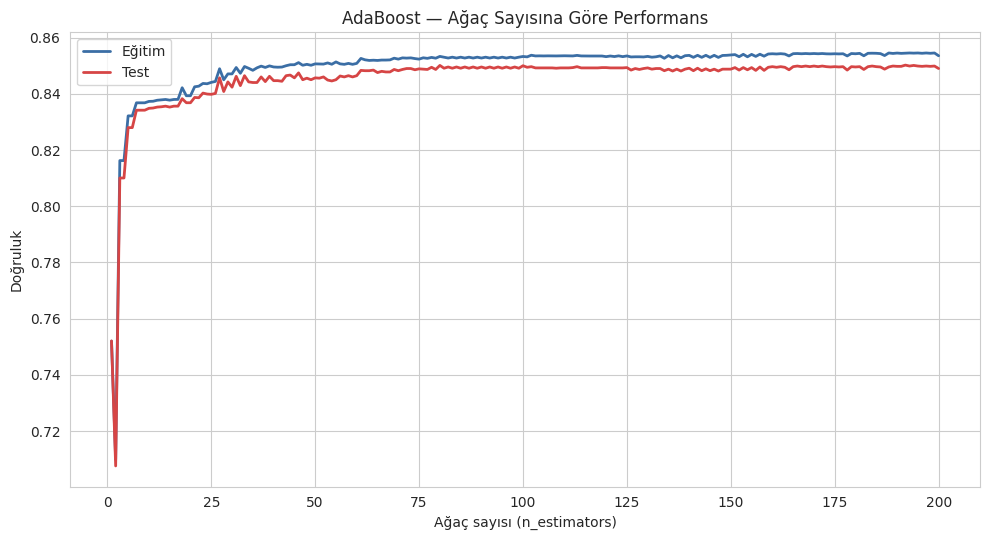

En iyi test doğruluğu: 0.8502 (192. ağaçta)


In [8]:
# ─── AdaBoost: Ağaç sayısı arttıkça performans nasıl değişiyor? ───────────────
# staged_score: her ek ağaçtan sonraki skoru verir (yeniden eğitmeye gerek yok)
egitim_skorlari = list(ada.staged_score(X_train, y_train))
test_skorlari   = list(ada.staged_score(X_test, y_test))

plt.figure(figsize=(10, 5.5))
plt.plot(range(1, len(egitim_skorlari) + 1), egitim_skorlari,
         color="#3b6ea5", linewidth=2, label="Eğitim")
plt.plot(range(1, len(test_skorlari) + 1), test_skorlari,
         color="#d64545", linewidth=2, label="Test")
plt.xlabel("Ağaç sayısı (n_estimators)")
plt.ylabel("Doğruluk")
plt.title("AdaBoost — Ağaç Sayısına Göre Performans")
plt.legend()
plt.tight_layout()
plt.show()

print(f"En iyi test doğruluğu: {max(test_skorlari):.4f} "
      f"({np.argmax(test_skorlari)+1}. ağaçta)")

In [9]:
# ─── XGBOOST MODELİ ───────────────────────────────────────────────────────────
print("🟢 XGBOOST EĞİTİLİYOR...")
t0 = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,             # AdaBoost'un tersine derin ağaçlar kullanır
    learning_rate=0.1,
    subsample=0.8,           # her ağaç için satırların %80'i
    colsample_bytree=0.8,    # her ağaç için sütunların %80'i
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)
xgb.fit(X_train, y_train)
xgb_sure = time.time() - t0

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"Eğitim süresi: {xgb_sure:.2f} saniye")
print(f"Doğruluk     : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC      : {roc_auc_score(y_test, y_proba_xgb):.4f}\n")
print(classification_report(y_test, y_pred_xgb, target_names=["<=50K", ">50K"], digits=3))

🟢 XGBOOST EĞİTİLİYOR...


Eğitim süresi: 1.18 saniye
Doğruluk     : 0.8652
ROC-AUC      : 0.9269

              precision    recall  f1-score   support

       <=50K      0.888     0.939     0.913      6795
        >50K      0.777     0.641     0.702      2240

    accuracy                          0.865      9035
   macro avg      0.832     0.790     0.807      9035
weighted avg      0.860     0.865     0.861      9035



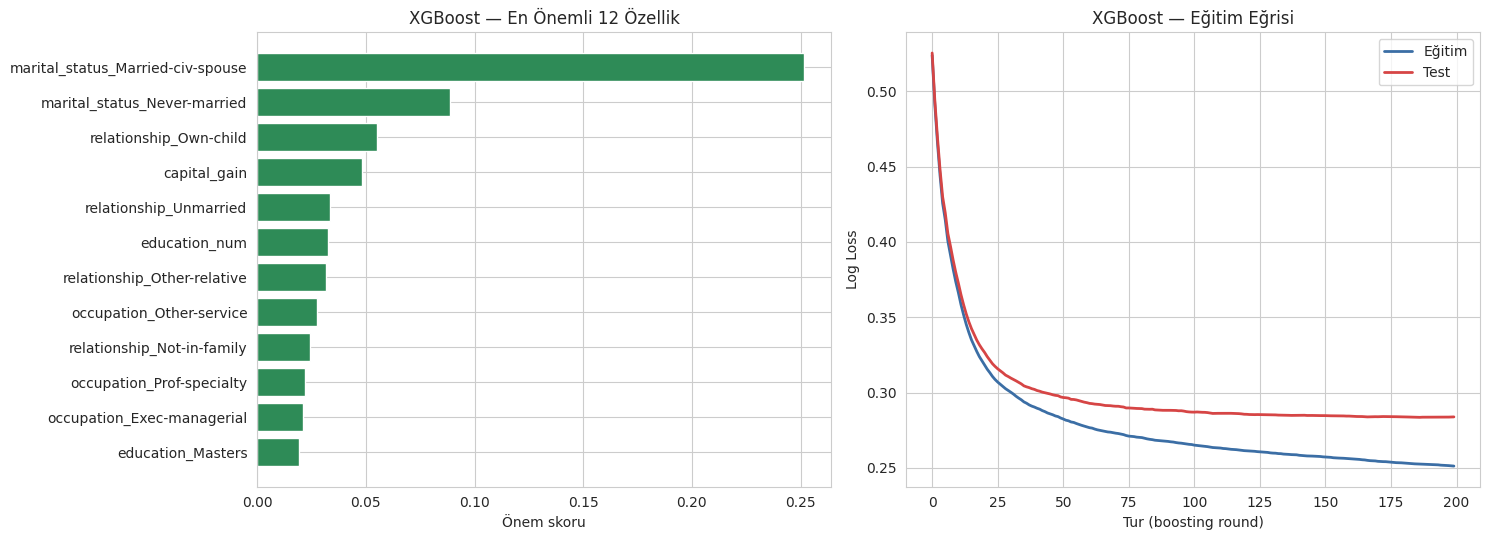

In [10]:
# ─── XGBoost: Özellik Önemi + Eğitim Eğrisi ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Sol: en önemli 12 özellik
onem = pd.Series(xgb.feature_importances_, index=X.columns).nlargest(12).sort_values()
axes[0].barh(onem.index, onem.values, color="#2e8b57")
axes[0].set_xlabel("Önem skoru")
axes[0].set_title("XGBoost — En Önemli 12 Özellik")

# Sağ: eğitim eğrisi (eval_set ile her turdaki kaybı izliyoruz)
xgb_izleme = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8, random_state=42,
                           n_jobs=-1, eval_metric="logloss")
xgb_izleme.fit(X_train, y_train,
               eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
gecmis = xgb_izleme.evals_result()

axes[1].plot(gecmis["validation_0"]["logloss"], color="#3b6ea5", linewidth=2, label="Eğitim")
axes[1].plot(gecmis["validation_1"]["logloss"], color="#d64545", linewidth=2, label="Test")
axes[1].set_xlabel("Tur (boosting round)"); axes[1].set_ylabel("Log Loss")
axes[1].set_title("XGBoost — Eğitim Eğrisi")
axes[1].legend()

plt.tight_layout()
plt.show()

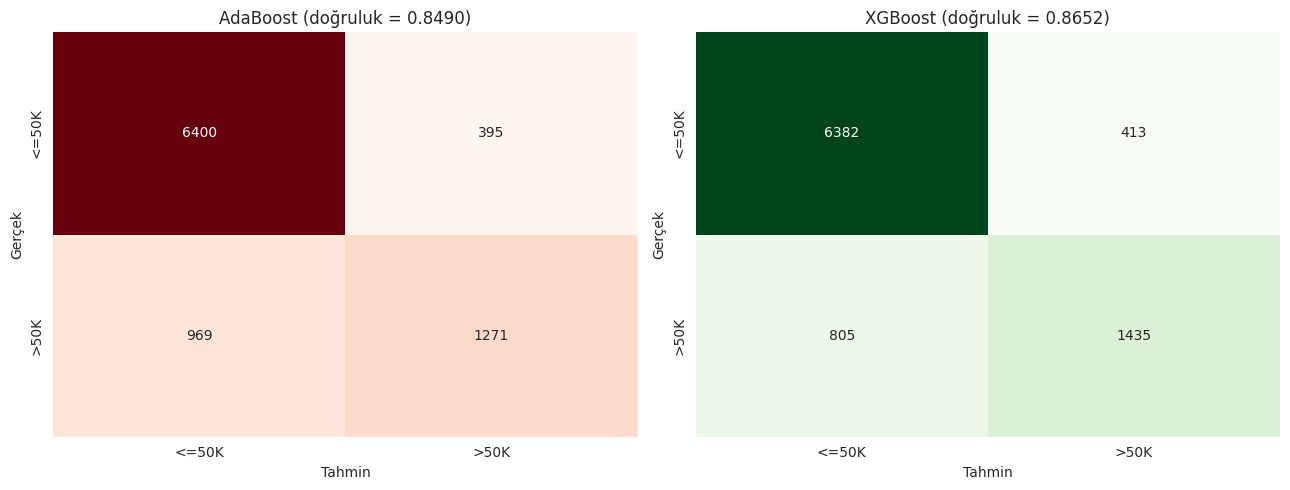

In [11]:
# ─── Karmaşıklık Matrisi Karşılaştırması ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (isim, tahmin, renk) in zip(axes, [("AdaBoost", y_pred_ada, "Reds"),
                                           ("XGBoost", y_pred_xgb, "Greens")]):
    cm = confusion_matrix(y_test, tahmin)
    sns.heatmap(cm, annot=True, fmt="d", cmap=renk, ax=ax, cbar=False,
                xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
    ax.set_title(f"{isim} (doğruluk = {accuracy_score(y_test, tahmin):.4f})")

plt.tight_layout()
plt.show()

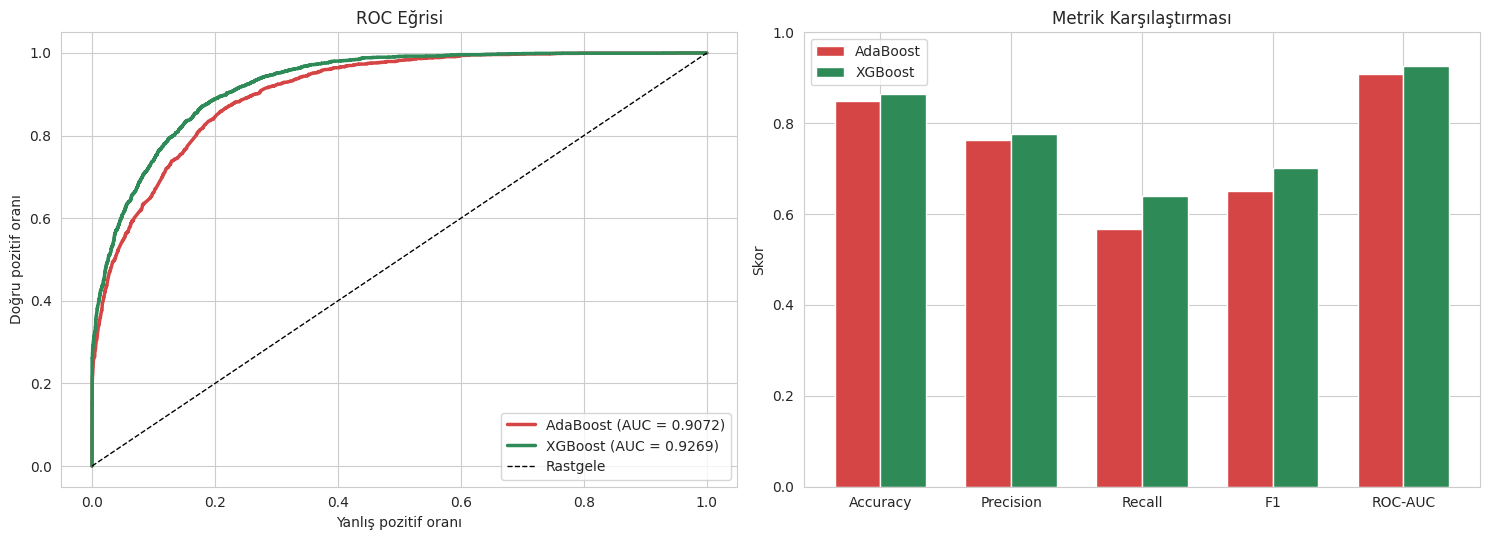

In [12]:
# ─── ROC Eğrisi + Metrik Karşılaştırması ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Sol: ROC eğrileri
for isim, proba, renk in [("AdaBoost", y_proba_ada, "#d64545"),
                          ("XGBoost", y_proba_xgb, "#2e8b57")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=renk, linewidth=2.5,
                 label=f"{isim} (AUC = {roc_auc_score(y_test, proba):.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Rastgele")
axes[0].set_xlabel("Yanlış pozitif oranı"); axes[0].set_ylabel("Doğru pozitif oranı")
axes[0].set_title("ROC Eğrisi"); axes[0].legend()

# Sağ: metrik bar grafiği
metrikler = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
ada_deg = [accuracy_score(y_test, y_pred_ada), precision_score(y_test, y_pred_ada),
           recall_score(y_test, y_pred_ada), f1_score(y_test, y_pred_ada),
           roc_auc_score(y_test, y_proba_ada)]
xgb_deg = [accuracy_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb),
           recall_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb),
           roc_auc_score(y_test, y_proba_xgb)]

x = np.arange(len(metrikler)); g = 0.35
axes[1].bar(x - g/2, ada_deg, g, label="AdaBoost", color="#d64545")
axes[1].bar(x + g/2, xgb_deg, g, label="XGBoost", color="#2e8b57")
axes[1].set_xticks(x); axes[1].set_xticklabels(metrikler)
axes[1].set_ylim(0, 1); axes[1].set_ylabel("Skor")
axes[1].set_title("Metrik Karşılaştırması"); axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# ─── 5-Fold Cross Validation ──────────────────────────────────────────────────
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
cv_ada = cross_val_score(AdaBoostClassifier(n_estimators=200, random_state=42),
                         X, y, cv=kf, scoring="roc_auc")
print(f"AdaBoost 5-Fold ROC-AUC: {np.round(cv_ada, 4)}")
print(f"  Ortalama: {cv_ada.mean():.4f} (± {cv_ada.std():.4f})  [{time.time()-t0:.1f} sn]")

t0 = time.time()
cv_xgb = cross_val_score(XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                       subsample=0.8, colsample_bytree=0.8,
                                       random_state=42, n_jobs=-1, eval_metric="logloss"),
                         X, y, cv=kf, scoring="roc_auc")
print(f"\nXGBoost 5-Fold ROC-AUC : {np.round(cv_xgb, 4)}")
print(f"  Ortalama: {cv_xgb.mean():.4f} (± {cv_xgb.std():.4f})  [{time.time()-t0:.1f} sn]")

AdaBoost 5-Fold ROC-AUC: [0.9119 0.9067 0.9076 0.9119 0.9101]
  Ortalama: 0.9097 (± 0.0021)  [26.1 sn]



XGBoost 5-Fold ROC-AUC : [0.9288 0.9252 0.9269 0.9299 0.9313]
  Ortalama: 0.9284 (± 0.0022)  [6.0 sn]


 2,000 satır -> AdaBoost  0.51 sn | XGBoost  0.14 sn


 8,000 satır -> AdaBoost  1.27 sn | XGBoost  0.30 sn


18,000 satır -> AdaBoost  2.44 sn | XGBoost  0.86 sn


36,000 satır -> AdaBoost  4.87 sn | XGBoost  1.12 sn


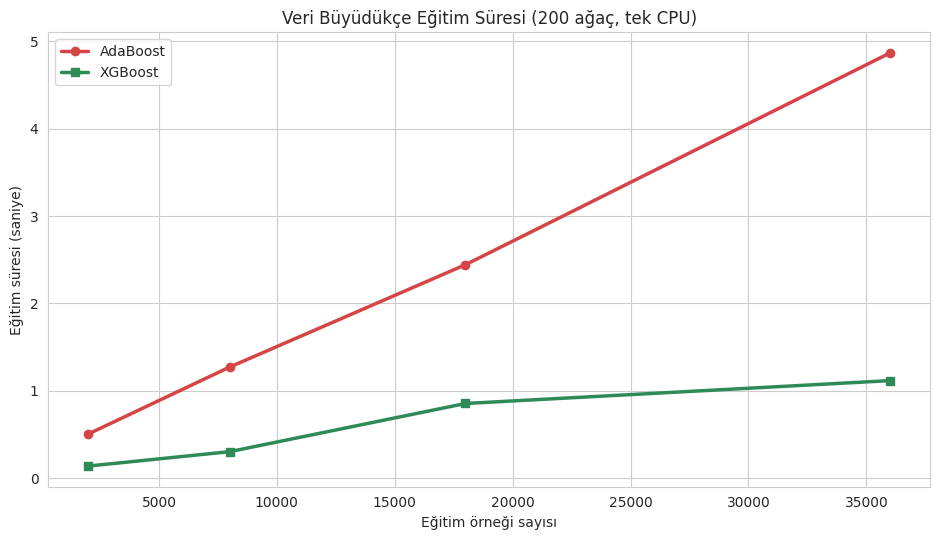

In [14]:
# ─── Farklı Veri Boyutlarında Eğitim Süresi ───────────────────────────────────
boyutlar = [2000, 8000, 18000, 36000]
sure_ada, sure_xgb = [], []

for n in boyutlar:
    Xn, yn = X_train.iloc[:n], y_train.iloc[:n]

    t0 = time.time()
    AdaBoostClassifier(n_estimators=200, random_state=42).fit(Xn, yn)
    sure_ada.append(time.time() - t0)

    t0 = time.time()
    XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
                  n_jobs=-1, eval_metric="logloss").fit(Xn, yn)
    sure_xgb.append(time.time() - t0)

    print(f"{n:>6,} satır -> AdaBoost {sure_ada[-1]:5.2f} sn | XGBoost {sure_xgb[-1]:5.2f} sn")

plt.figure(figsize=(9.5, 5.5))
plt.plot(boyutlar, sure_ada, "o-", color="#d64545", linewidth=2.5, label="AdaBoost")
plt.plot(boyutlar, sure_xgb, "s-", color="#2e8b57", linewidth=2.5, label="XGBoost")
plt.xlabel("Eğitim örneği sayısı"); plt.ylabel("Eğitim süresi (saniye)")
plt.title("Veri Büyüdükçe Eğitim Süresi (200 ağaç, tek CPU)")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ─── Nihai Sonuç Tablosu ──────────────────────────────────────────────────────
ozet = pd.DataFrame({
    "Metrik": ["Doğruluk", "Precision (>50K)", "Recall (>50K)", "F1 (>50K)",
               "ROC-AUC (test)", "ROC-AUC (5-fold)", "Eğitim süresi (sn)"],
    "AdaBoost": [round(v, 4) for v in ada_deg] + [round(cv_ada.mean(), 4), round(ada_sure, 2)],
    "XGBoost":  [round(v, 4) for v in xgb_deg] + [round(cv_xgb.mean(), 4), round(xgb_sure, 2)],
})
ozet["Kazanan"] = np.where(ozet["Metrik"] == "Eğitim süresi (sn)",
                           np.where(ozet["XGBoost"] < ozet["AdaBoost"], "XGBoost", "AdaBoost"),
                           np.where(ozet["XGBoost"] > ozet["AdaBoost"], "XGBoost", "AdaBoost"))
ozet

,Metrik,AdaBoost,XGBoost,Kazanan
0,Doğruluk,0.8490,0.8652,XGBoost
1,Precision (>50K),0.7629,0.7765,XGBoost
2,Recall (>50K),0.5674,0.6406,XGBoost
3,F1 (>50K),0.6508,0.7021,XGBoost
4,ROC-AUC (test),0.9072,0.9269,XGBoost
5,ROC-AUC (5-fold),0.9097,0.9284,XGBoost
6,Eğitim süresi (sn),5.2700,1.1800,XGBoost


In [16]:
# ─── En Belirleyici Özellikler: İki Model Ne Diyor? ───────────────────────────
onem_ada = pd.Series(ada.feature_importances_, index=X.columns).nlargest(8)
onem_xgb = pd.Series(xgb.feature_importances_, index=X.columns).nlargest(8)

karsilastirma = pd.DataFrame({
    "AdaBoost — ilk 8": onem_ada.index,
    "Önem (Ada)": onem_ada.round(4).values,
    "XGBoost — ilk 8": onem_xgb.index,
    "Önem (XGB)": onem_xgb.round(4).values,
})
karsilastirma

,AdaBoost — ilk 8,Önem (Ada),XGBoost — ilk 8,Önem (XGB)
0,capital_gain,0.2256,marital_status_Married-civ-spouse,0.2515
1,marital_status_Married-civ-spouse,0.1509,marital_status_Never-married,0.0887
2,capital_loss,0.1442,relationship_Own-child,0.0549
3,education_num,0.1017,capital_gain,0.0480
4,age,0.0904,relationship_Unmarried,0.0334
5,marital_status_Married-AF-spouse,0.0538,education_num,0.0324
6,hours_per_week,0.0499,relationship_Other-relative,0.0314
7,occupation_Farming-fishing,0.0255,occupation_Other-service,0.0275
